## 깔끔한 데이터 만들기
> 데이터분석을 용이하게 하고 시각화를 수월하게 하기 위해서 데이터프레임이 깔끔한 구조를 가지는 것이 좋음.


깔끔한 데이터란? - 
1. 변수은 column(열)로 구성
2. 관측값은 row(행)로 구성
3. 값은 cell(셀)에 작성

위 규칙에 맞지 않게 만들어져 있는 데이터셋이 있다면 구조를 변경하여 깔끔한 데이터프레임으로 만들어서 분석함.  

**사례별로 구조를 변경하면 깔끔한 데이터를 만들어보기**

In [1]:
#1. 열 이름이 관측값이 경우...(안좋은 구조)
# 비 깔끔한 데이터
import pandas as pd
data = [
    ["서울", 10, 12, 15],
    ["부산", 7, 9, 11]
]

df = pd.DataFrame(data, columns=["지역", "2021", "2022", "2023"])
df

,지역,2021,2022,2023
0,서울,10,12,15
1,부산,7,9,11


In [2]:
#문제1. 연도별 평균 판매액 구하기
df[['2021','2022','2023']].mean()
# 문제점.
# 연도 컬룸명을 직접 나열해야함. 
# 연도를 변수처럼 다루지 않아서...직관적이지 않음.

2021     8.5
2022    10.5
2023    13.0
dtype: float64

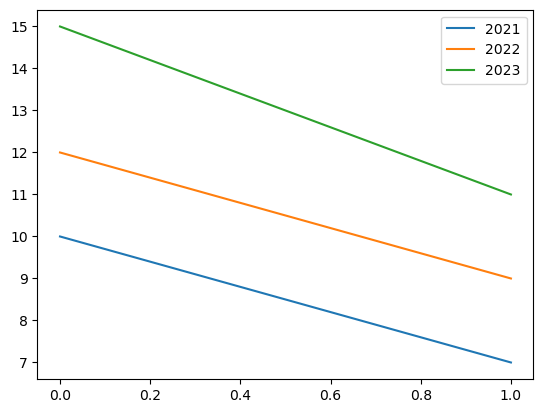

In [4]:
#문제2. 시각화 할때 짜증 -- 뭔지 잘 안 읽어짐
#통상적으로 그래프를 그릴때..
#관측값들이 x축
#각 변수의 값들이 y축 

#연도별 추이를 그리고 싶어...
import matplotlib.pyplot as plt

plt.plot(df['2021'], label='2021')
plt.plot(df['2022'], label='2022')
plt.plot(df['2023'], label='2023')
plt.legend()
plt.show()

In [5]:
#깔끔한 데이터로 변경.. 방법 [ .melt() ]
df_tidy = df.melt(
    id_vars='지역',     # 그대로 유지될 컬룸 지정
    value_vars=['2021','2022','2023'],  # '녹여서' 행으로 변환될 컬룸명등.(지정하지 않으면 모두)
    var_name='연도',     # 기존 컬룸명이 값이된 컬룸의 이름지정
    value_name='매출액'  # 값들이 들어간 컬룸의 이름지정
)
df_tidy

,지역,연도,매출액
0,서울,2021,10
1,부산,2021,7
2,서울,2022,12
3,부산,2022,9
4,서울,2023,15
5,부산,2023,11
